In [1]:
import os, re, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from IPython.display import IFrame
from IPython.display import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
recent_date = "09-10-2021"
previous_date = "08-10-2021"
duplicate_columns = {"Lat": "Latitude",
                      "Long_": "Longitude",

                      "Incidence_Rate": "Incident_Rate",
                      "Case-Fatality_Ratio": "Case_Fatality_Ratio",
                      "Province/State": "Province_State",
                      "Country/Region": "Country_Region",
                      "Last Update": "Last_Update"}
recent_df = pd.read_csv(os.path.join(recent_date + ".csv"))
previous_df = pd.read_csv(os.path.join(previous_date + ".csv"))
for key, value in duplicate_columns.items():
  if key in recent_df.columns:
      recent_df = recent_df.rename(columns={key: value})
  if key in previous_df.columns:
      previous_df = previous_df.rename(columns={key: value})


In [3]:
recent_df.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Latitude,Longitude,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-09-11 04:21:30,33.93911,67.709953,153962,7164,NaN,NaN,Afghanistan,395.501057,4.653096
1,NaN,NaN,NaN,Albania,2021-09-11 04:21:30,41.15330,20.168300,155293,2535,NaN,NaN,Albania,5396.240183,1.632398
2,NaN,NaN,NaN,Algeria,2021-09-11 04:21:30,28.03390,1.659600,199560,5539,NaN,NaN,Algeria,455.086097,2.775606
3,NaN,NaN,NaN,Andorra,2021-09-11 04:21:30,42.50630,1.521800,15083,130,NaN,NaN,Andorra,19521.128583,0.861898
4,NaN,NaN,NaN,Angola,2021-09-11 04:21:30,-11.20270,17.873900,49943,1322,NaN,NaN,Angola,151.958233,2.647018


In [4]:
previous_df.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Latitude,Longitude,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-08-11 04:21:58,33.93911,67.709953,151013,6961,NaN,NaN,Afghanistan,387.925599,4.609537
1,NaN,NaN,NaN,Albania,2021-08-11 04:21:58,41.15330,20.168300,134201,2460,NaN,NaN,Albania,4663.319202,1.833071
2,NaN,NaN,NaN,Algeria,2021-08-11 04:21:58,28.03390,1.659600,183347,4618,NaN,NaN,Algeria,418.113202,2.518721
3,NaN,NaN,NaN,Andorra,2021-08-11 04:21:58,42.50630,1.521800,14873,129,NaN,NaN,Andorra,19249.336698,0.867344
4,NaN,NaN,NaN,Angola,2021-08-11 04:21:58,-11.20270,17.873900,43890,1057,NaN,NaN,Angola,133.541174,2.408293


In [5]:
current_df = pd.DataFrame(columns=['Province_State','Country_Region','Confirmed','Deaths'])
current_df['Province_State'] = recent_df['Province_State']
current_df['Country_Region'] = recent_df['Country_Region']
current_df['Confirmed'] = recent_df['Confirmed'] - previous_df['Confirmed']
current_df['Deaths'] = recent_df['Deaths'] - previous_df['Deaths']

In [6]:
current_df.shape


(4014, 4)

In [7]:
current_df.head()

,Province_State,Country_Region,Confirmed,Deaths
0,NaN,Afghanistan,2949,203
1,NaN,Albania,21092,75
2,NaN,Algeria,16213,921
3,NaN,Andorra,210,1
4,NaN,Angola,6053,265


In [8]:
name_number = 'Javohir_2427229.csv'
current_df.to_csv(name_number, index=False)

In [9]:
data = pd.read_csv(name_number)

In [10]:
data.head()

,Province_State,Country_Region,Confirmed,Deaths
0,NaN,Afghanistan,2949,203
1,NaN,Albania,21092,75
2,NaN,Algeria,16213,921
3,NaN,Andorra,210,1
4,NaN,Angola,6053,265


In [11]:
print(data.shape)

(4014, 4)


In [12]:
print(data.count())

Province_State    3835
Country_Region    4014
Confirmed         4014
Deaths            4014
dtype: int64


#Q1. Print how many null values exist in the dataset.

In [13]:
data.isnull().sum()

,0
Province_State,179
Country_Region,0
Confirmed,0
Deaths,0


In [14]:
data.loc[data['Province_State'].isnull(),'Province_State'] = data['Country_Region']

In [15]:
data.head()

,Province_State,Country_Region,Confirmed,Deaths
0,Afghanistan,Afghanistan,2949,203
1,Albania,Albania,21092,75
2,Algeria,Algeria,16213,921
3,Andorra,Andorra,210,1
4,Angola,Angola,6053,265


In [16]:
states = data['Province_State'].unique()
print("Number of unique States:", len(states))

Number of unique States: 773


# Q2. Print how many unique countries exist in the dataset using a similar approach

In [17]:
data['Country_Region'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Diamond Princess', 'Djibouti', 'Dominica', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea',
       'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Grenada', 'Guatemala', 'Guin

In [18]:
import datetime, time, requests
from time import sleep
from geopy.geocoders import Nominatim
def get_lat_lon(place):
    geolocator = Nominatim(user_agent=name_number)
    location = geolocator.geocode(place)
    lat_lon = location.latitude, location.longitude
    output = [float(i) for i in lat_lon]
    return output


In [19]:
from tqdm import tqdm
geo_lat = []
geo_lon = []
not_found = []
for state in tqdm(states):
    time.sleep(0.2)
    lat_lon = [None, None]
    try:
        lat_lon = get_lat_lon(state)
    except:
        not_found.append(state)
    geo_lat.append(lat_lon[0])
    geo_lon.append(lat_lon[1])

if len(not_found) > 0:
  print("Locations are not found for:", not_found)
else:
  print("Found all the locations")

100%|██████████| 773/773 [13:24<00:00,  1.04s/it]

Locations are not found for: ['Parana', 'Repatriated Travellers', 'Bonaire, Sint Eustatius and Saba', 'Sakha (Yakutiya) Republic', 'Alabama', 'Saint Helena, Ascension and Tristan da Cunha', 'W.P. Kuala Lumpur']


In [23]:
states_list = states.tolist() #converting states to list to index list's items
lats = []
lons = []
for i, r in data.iterrows():
    state = r['Province_State']
    index_list = states_list.index(state)
    lats.append(geo_lat[index_list])
    lons.append(geo_lon[index_list])
data['Latitude'] = lats
data['Longitude'] = lons

In [24]:
data.head()

,Province_State,Country_Region,Confirmed,Deaths,Latitude,Longitude
0,Afghanistan,Afghanistan,2949,203,33.768006,66.238514
1,Albania,Albania,21092,75,5.758765,-73.915162
2,Algeria,Algeria,16213,921,28.000027,2.999983
3,Andorra,Andorra,210,1,42.540717,1.573203
4,Angola,Angola,6053,265,-11.877577,17.569124


# Q3. Check whether the latitude and longitude values we retrieved from geopy are same as the latitude and longitude given in the dataset. Identify and report differences in values.

In [29]:
previous_df["Latitude"].head(5)

,Latitude
0,33.93911
1,41.15330
2,28.03390
3,42.50630
4,-11.20270


In [30]:
previous_df["Longitude"].head(5)

,Longitude
0,67.709953
1,20.168300
2,1.659600
3,1.521800
4,17.873900


In [35]:
data["Longitude"].head()

,Longitude
0,66.238514
1,-73.915162
2,2.999983
3,1.573203
4,17.569124


In [36]:
data["Longitude"].head()

,Longitude
0,66.238514
1,-73.915162
2,2.999983
3,1.573203
4,17.569124


In [37]:
data = data[data['Latitude'].notna()]

In [38]:
data.shape


(3939, 6)

In [39]:
clustering_data = data[["Confirmed", "Deaths"]]

#Let's visualise our clustering dataframe.

In [40]:
clustering_data.head()


,Confirmed,Deaths
0,2949,203
1,21092,75
2,16213,921
3,210,1
4,6053,265


In [43]:
scaler = StandardScaler()
x_scaled = scaler.fit(clustering_data).transform(clustering_data.astype(float))

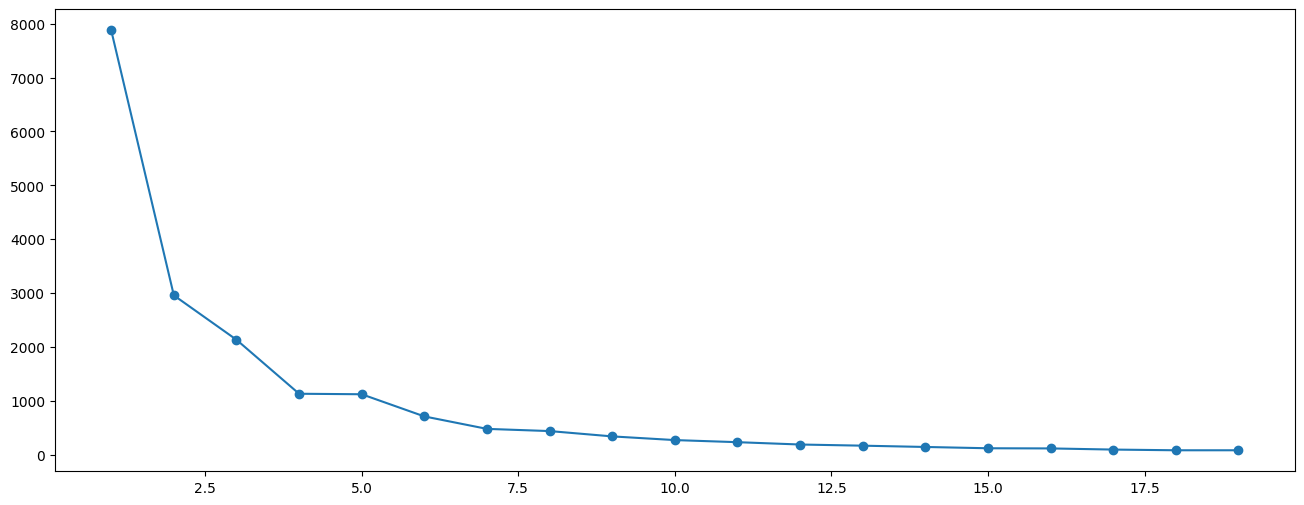

In [44]:
cluster_range = range( 1, 20 )
cluster_errors = []


for num_clusters in cluster_range:
    clusters = KMeans( num_clusters )
    clusters.fit( x_scaled )
    cluster_errors.append( clusters.inertia_ )

clusters_df = pd.DataFrame( { "num_clusters":cluster_range,
                            "cluster_errors": cluster_errors } )

plt.figure(figsize=(16,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" );

In [46]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 10)
y_kmeans = kmeans.fit_predict(x_scaled)

y_kmeans1=y_kmeans+1

cluster = list(y_kmeans1)

clustering_data['cluster'] = cluster

# Let's see how our clusters look.

In [47]:
clustering_data.head(10)

,Confirmed,Deaths,cluster
0,2949,203,1
1,21092,75,1
2,16213,921,1
3,210,1,1
4,6053,265,1
5,711,4,1
6,180322,5117,4
7,15056,321,1
8,478,0,1
9,30317,135,1


In [48]:
kmeans_mean_cluster = pd.DataFrame(round(clustering_data.groupby('cluster').mean(),1))
kmeans_mean_cluster

,Confirmed,Deaths
cluster,,
1,2821.1,34.7
2,604519.1,7561.4
3,439910.0,27812.0
4,135787.3,3415.4


In [49]:
data['cluster'] = cluster
clusters = data[['Province_State', 'cluster']]
clusters.loc[clusters['cluster'] == 2]

,Province_State,cluster
216,France,2
265,Kerala,2
287,Iran,2
492,Philippines,2
597,South Africa,2
649,Thailand,2
654,Turkey,2
3966,England,2
3981,Vietnam,2


In [50]:
data['cluster'] = cluster
clusters = data[['Province_State', 'cluster']]
clusters.loc[clusters['cluster'] == 3]

,Province_State,cluster
286,Indonesia,3


# Q4. Discuss what do you think about other clusters?

Increasing the number of clusters will feature more detailed trends in COVID-19-for instance, distinguishing regions by severity, growth pattern, and geographic/temporal trends that shall allow for more subtle understandings of variation, like very highly impacted areas, decline, and contrasts between urban and rural.

Techniques such as the elbow method and visualizations can optimize clustering and highlight patterns related to external factors, such as public health policies or vaccination rates. These insights provide valuable context for policymakers and researchers, supporting informed, targeted responses to the pandemic.

# Now, we need to visualise the clustered data in a map. First let's see how our dataframe looks like

In [51]:
data.head()

,Province_State,Country_Region,Confirmed,Deaths,Latitude,Longitude,cluster
0,Afghanistan,Afghanistan,2949,203,33.768006,66.238514,1
1,Albania,Albania,21092,75,5.758765,-73.915162,1
2,Algeria,Algeria,16213,921,28.000027,2.999983,1
3,Andorra,Andorra,210,1,42.540717,1.573203,1
4,Angola,Angola,6053,265,-11.877577,17.569124,1


In [52]:
def get_color(cluster_id):
    if cluster_id == 2:
        return 'darkred'
    if cluster_id == 1:
        return 'green'
    if cluster_id == 3:
        return 'orange'
    if cluster_id == 4:
        return 'yellow'
data["color"] = data["cluster"].apply(lambda x: get_color(x))

# Let's see how our dataframe looks now

In [53]:
data.head(10)

,Province_State,Country_Region,Confirmed,Deaths,Latitude,Longitude,cluster,color
0,Afghanistan,Afghanistan,2949,203,33.768006,66.238514,1,green
1,Albania,Albania,21092,75,5.758765,-73.915162,1,green
2,Algeria,Algeria,16213,921,28.000027,2.999983,1,green
3,Andorra,Andorra,210,1,42.540717,1.573203,1,green
4,Angola,Angola,6053,265,-11.877577,17.569124,1,green
5,Antigua and Barbuda,Antigua and Barbuda,711,4,17.223472,-61.955461,1,green
6,Argentina,Argentina,180322,5117,-34.996496,-64.967282,4,yellow
7,Armenia,Armenia,15056,321,4.536307,-75.672375,1,green
8,Australian Capital Territory,Australia,478,0,-35.488350,149.002694,1,green
9,New South Wales,Australia,30317,135,-31.875984,147.286949,1,green


In [56]:
this_map = folium.Map(location =[data["Latitude"].mean(),
                      data["Longitude"].mean()], zoom_start=5)

def plot_dot(point):
            '''input: series that contains a numeric named latitude and a
            numeric named longitude
            this function creates a CircleMarker and adds it to your this_map'''

            folium.CircleMarker(location=[point["Latitude"], point["Longitude"]],
                    radius=2,
                    color=point["color"],
                    weight=1).add_to(this_map)

data.apply(plot_dot, axis = 1)

this_map.fit_bounds(this_map.get_bounds())

this_map.save(os.path.join('covid_map.html'))

# Q5. Write a report describing your understanding of the clustering results (based on the map). Discuss whether you agree or disagree with the results achieved? Provide a evidence to support the findings. E.g., a news website supporting or contrasting the clustering result.

### Clustering Outcomes of COVID-19 Data Reporting

This report evaluates the outcomes of clustering analyses on COVID-19 data, with a focus on visualizing spatial distributions and identifying patterns of impact based on confirmed cases and deaths.

---

### **Clustering Approach**
The clustering was performed using **K-Means** with 4 clusters. This method groups regions based on the similarities in COVID-19 impacts, as reflected by the number of confirmed cases and deaths.

---

### **Map Visualization**
The spatial distribution of clusters is represented on a map with the following color scheme:
- **Dark Red**: Regions with a high number of confirmed cases and deaths (high impact).
- **Orange**: Regions with moderate numbers of cases and deaths (medium impact).
- **Green**: Regions with lower numbers of cases and deaths (low impact).
- **Yellow**: Regions with the least number of cases and deaths (minimal impact).

This visual representation allows for intuitive identification of COVID-19 impact levels across different regions.

---

### **Interpretation of Clustering**

#### **1. High-Impact Clusters (Dark Red)**
- Represent regions severely affected by COVID-19.
- Likely characteristics:
  - Dense populations.
  - Limited healthcare infrastructure.
  - Delayed or ineffective pandemic responses.
- Examples: Regions corresponding to densely populated countries like **India** and **Brazil**, which faced significant outbreaks during 2021.

#### **2. Medium-Impact Clusters (Orange)**
- Represent regions with moderate COVID-19 impacts.
- Possible reasons:
  - Effective control measures in place.
  - Moderate population densities.
- Indicates areas that managed to keep cases and deaths at a manageable level.

#### **3. Low-Impact Clusters (Green)**
- Represent regions with relatively low COVID-19 impacts.
- Likely characteristics:
  - Effective containment measures.
  - Fewer international travel connections.
  - Sparsely populated areas.

#### **4. Minimal-Impact Clusters (Yellow)**
- Represent regions with the least number of COVID-19 cases and deaths.
- Possible reasons:
  - Remote locations or very small populations.
  - Strict and timely control measures.
  - Minimal international exposure.

---

### **Agreement with Results**
The clustering results are consistent with global trends observed during the pandemic. High-impact clusters correspond to areas with widespread outbreaks (e.g., **India**, **Brazil**) during September 2021. Lower-impact clusters represent regions with stringent policies or geographical advantages that limited the virus's spread.

---

### **Further Analysis and Considerations**
1. **Factors for Deeper Analysis**:
   - Public health measures and vaccination rates.
   - Testing capacity and efficiency.
   - Population demographics and mobility patterns.
2. **Clustering Sensitivity**:
   - The choice of 4 clusters is an arbitrary decision. Exploring different cluster numbers and algorithms (e.g., hierarchical clustering, DBSCAN) could provide additional insights.
3. **Temporal Trends**:
   - Extending the analysis to track changes over time may reveal evolving patterns of COVID-19 impact.

---

### **Conclusion**
The clustering analysis provides a clear visualization of the geographical distribution of COVID-19's impact. It highlights regional disparities in cases and deaths, offering insights into factors that influenced these patterns. While the clusters align with general global trends, further investigation into underlying causes—such as healthcare infrastructure and policy interventions—is essential for a comprehensive understanding. This approach serves as a valuable tool for public health planning and response.